In [2]:
import pandas as pd

# Load the Excel file
file_path = 'Provider and Member Data.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load individual sheets into DataFrames
data_dict = excel_data.parse('Data Dictionary')
claim_header = excel_data.parse('Claim Header')
claim_line = excel_data.parse('Claim Line')
member = excel_data.parse('Member')
provider = excel_data.parse('Provider')


In [3]:
claim_header.head()
claim_line.head()
member.head()
provider.head()


,Provider_NPI,Provider Name,Contract_Effective_Date
0,451387550,Provider 1,1998-12-08 00:00:00
1,451416310,Provider 2,1986-12-11 00:00:00
2,451460835,Provider 3,1985-03-01 00:00:00
3,451716956,Provider 4,1983-07-10 00:00:00
4,451718872,Provider 5,1998-06-01 00:00:00


In [5]:
# Load individual sheets with ? and ~ treated as NaN
data_dict = excel_data.parse('Data Dictionary', na_values=['?', '~'])
claim_header = excel_data.parse('Claim Header', na_values=['?', '~'])
claim_line = excel_data.parse('Claim Line', na_values=['?', '~'])
member = excel_data.parse('Member', na_values=['?', '~'])
provider = excel_data.parse('Provider', na_values=['?', '~'])


In [21]:
claim_header.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Claim_Key          206 non-null    int64         
 1   Location           206 non-null    object        
 2   ADJSTMT_SEQ_NUM    206 non-null    int64         
 3   Diagnosis_Code     206 non-null    object        
 4   Claim_Filing_Code  206 non-null    int64         
 5   DISP_CD            206 non-null    object        
 6   DRG_CD             23 non-null     float64       
 7   Member_Key         204 non-null    float64       
 8   Received_DT        206 non-null    datetime64[ns]
 9   Provider_NPI       206 non-null    int64         
 10  DSCHRG_DT          27 non-null     float64       
 11  ADM_DT             27 non-null     float64       
 12  INPAT_OUTPAT_CD    27 non-null     float64       
 13  Allowed_Amount     206 non-null    float64       
 14  Paid_Amoun

In [22]:
# Check for null values
print(claim_header.isnull().sum())

Claim_Key              0
Location               0
ADJSTMT_SEQ_NUM        0
Diagnosis_Code         0
Claim_Filing_Code      0
DISP_CD                0
DRG_CD               183
Member_Key             2
Received_DT            0
Provider_NPI           0
DSCHRG_DT            179
ADM_DT               179
INPAT_OUTPAT_CD      179
Allowed_Amount         0
Paid_Amount            0
dtype: int64


In [62]:
import pandas as pd

# Handle missing values

claim_header['Member_Key'] = claim_header['Member_Key'].fillna(claim_header['Member_Key'].mean())

claim_header['DRG_CD'] = claim_header['DRG_CD'].fillna(claim_header['DRG_CD'].mode()[0])

claim_header['DSCHRG_DT'] = claim_header['DSCHRG_DT'].fillna(method='ffill')
claim_header['ADM_DT'] = claim_header['ADM_DT'].fillna(method='bfill')

claim_header['INPAT_OUTPAT_CD'] = claim_header['INPAT_OUTPAT_CD'].fillna(claim_header['INPAT_OUTPAT_CD'].mode()[0])

print(claim_header.isnull().sum())


Claim_Key            0
Location             0
ADJSTMT_SEQ_NUM      0
Diagnosis_Code       0
Claim_Filing_Code    0
DISP_CD              0
DRG_CD               0
Member_Key           0
Received_DT          0
Provider_NPI         0
DSCHRG_DT            1
ADM_DT               3
INPAT_OUTPAT_CD      0
Allowed_Amount       0
Paid_Amount          0
Year                 0
dtype: int64


/var/folders/6m/366s5m851yvcbrw5bk471cbh0000gn/T/ipykernel_49080/1624831043.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  claim_header['DSCHRG_DT'] = claim_header['DSCHRG_DT'].fillna(method='ffill')
/var/folders/6m/366s5m851yvcbrw5bk471cbh0000gn/T/ipykernel_49080/1624831043.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  claim_header['ADM_DT'] = claim_header['ADM_DT'].fillna(method='bfill')


In [18]:
print(claim_line.isnull().sum())

Claim_Key            0
Paid_Date            0
Line_Number          3
INPAT_OUTPAT_CD    313
Diagnosis_Code       0
HCPCS_CPT_CD         0
Modifier_Code        0
PLC_OF_TRMNT_CD      0
RVNU_CD            313
SVC_FROM_DT          0
SVC_TO_DT            0
SVC_UNIT_CNT         0
Billed_Amount        0
Allowed_Amount       0
Paid_Amount          0
dtype: int64


In [63]:
# Cleaning Line_Number 
claim_line['Line_Number'] = claim_line['Line_Number'].fillna(claim_line['Line_Number'].mode()[0])

# Cleaning INPAT_OUTPAT_CD 
claim_line['INPAT_OUTPAT_CD'] = claim_line['INPAT_OUTPAT_CD'].fillna(claim_line['INPAT_OUTPAT_CD'].mode()[0])

# Cleaning RVNU_CD 
claim_line['RVNU_CD'] = claim_line['RVNU_CD'].fillna(claim_line['RVNU_CD'].mode()[0])

print(claim_line.isnull().sum())


Claim_Key          0
Paid_Date          0
Line_Number        0
INPAT_OUTPAT_CD    0
Diagnosis_Code     0
HCPCS_CPT_CD       0
Modifier_Code      0
PLC_OF_TRMNT_CD    0
RVNU_CD            0
SVC_FROM_DT        0
SVC_TO_DT          0
SVC_UNIT_CNT       0
Billed_Amount      0
Allowed_Amount     0
Paid_Amount        0
dtype: int64


In [19]:
print(member.isnull().sum())

Member_Key     0
Member_Name    2
DOB            7
dtype: int64


In [64]:
# Fill Member_Name with a placeholder for missing names
member['Member_Name'] = member['Member_Name'].fillna('Unknown')

# Fill DOB 
median_age = (pd.Timestamp('today') - pd.to_datetime(member['DOB'], errors='coerce')).dt.days.median() / 365
median_dob = pd.Timestamp('today') - pd.to_timedelta(median_age * 365, unit='days')
member['DOB'] = member['DOB'].fillna(median_dob)

print(member.isnull().sum())


Member_Key     0
Member_Name    0
DOB            0
Age            8
dtype: int64


In [20]:
print(provider.isnull().sum())

Provider_NPI               0
Provider Name              3
Contract_Effective_Date    0
dtype: int64


In [66]:
# Fill missing Provider Name with a placeholder
provider['Provider Name'] = provider['Provider Name'].fillna('Unknown Provider')
print(provider.isnull().sum())


Provider_NPI               0
Provider Name              0
Contract_Effective_Date    0
dtype: int64


In [67]:
#1. Provide and interpret summary statistics on IL claims paid in 2018
# Convert Received_DT to datetime format and extract the year
claim_header['Received_DT'] = pd.to_datetime(claim_header['Received_DT'])
claim_header['Year'] = claim_header['Received_DT'].dt.year

# Filter data for claims in Illinois (IL1) and for the year 2018
il_claims_2018 = claim_header[(claim_header['Location'] == 'IL1') & (claim_header['Year'] == 2018)]

# Calculate summary statistics for the Paid_Amount column
summary_stats_il_claims = il_claims_2018['Paid_Amount'].describe()

# Paid amount sum and count
total_paid = il_claims_2018['Paid_Amount'].sum()
num_claims = il_claims_2018['Paid_Amount'].count()

print("Summary Statistics for IL Claims Paid in 2018:")
print(summary_stats_il_claims)
print(f"\nTotal Paid Amount: ${total_paid:,.2f}")
print(f"Number of Claims: {num_claims}")



Summary Statistics for IL Claims Paid in 2018:
count      71.000000
mean      101.567873
std       687.284928
min         0.000000
25%         2.547750
50%         7.302000
75%        18.810000
max      5799.799500
Name: Paid_Amount, dtype: float64

Total Paid Amount: $7,211.32
Number of Claims: 71


In [68]:
#2. Provide and interpret summary statistics on members who are less than 60 years of age
# Convert DOB to datetime and calculate age
today = pd.Timestamp('today')
member['DOB'] = pd.to_datetime(member['DOB'], errors='coerce')  # Handle invalid dates as NaT
member['Age'] = (today - member['DOB']).dt.days / 365  # Convert days to years

# Filter members under 60 years of age
members_under_60 = member[member['Age'] < 60]

# Calculate summary statistics for the Age column
summary_stats_members_under_60 = members_under_60['Age'].describe()

#total members and the youngest and oldest in the filtered group
total_members_under_60 = members_under_60.shape[0]
youngest_member = members_under_60['Age'].min()
oldest_member = members_under_60['Age'].max()

print("Summary Statistics for Members Under 60 Years of Age:")
print(summary_stats_members_under_60)
print(f"\nTotal Members Under 60: {total_members_under_60}")
print(f"Youngest Member's Age: {youngest_member:.2f} years")
print(f"Oldest Member's Age: {oldest_member:.2f} years")


Summary Statistics for Members Under 60 Years of Age:
count    796.000000
mean      50.691918
std        6.774648
min        4.991781
25%       47.843836
50%       51.208219
75%       55.347945
max       59.591781
Name: Age, dtype: float64

Total Members Under 60: 796
Youngest Member's Age: 4.99 years
Oldest Member's Age: 59.59 years


In [69]:
#3. Create a member-to-provider attribution list
# Merge Claim_Header with Claim_Line to link Member_Key with Provider_NPI
member_provider_mapping = claim_line.merge(
    claim_header[['Claim_Key', 'Member_Key', 'Provider_NPI']],
    on='Claim_Key',
    how='left'
)[['Member_Key', 'Provider_NPI']]

# Drop duplicate entries 
member_provider_mapping = member_provider_mapping.drop_duplicates()

# Add Member_Name and Provider_Name
member_provider_mapping = member_provider_mapping.merge(
    member[['Member_Key', 'Member_Name']],
    on='Member_Key',
    how='left'
).merge(
    provider[['Provider_NPI', 'Provider Name']],
    on='Provider_NPI',
    how='left'
)[['Member_Key', 'Member_Name', 'Provider_NPI', 'Provider Name']]

print("Member-to-Provider Attribution List:")
print(member_provider_mapping.head())

# Count the number of members per provider to understand workload distribution
provider_member_count = member_provider_mapping.groupby('Provider_NPI').size().reset_index(name='Member_Count')

print("\nNumber of Members Per Provider:")
print(provider_member_count.sort_values(by='Member_Count', ascending=False).head())

Member-to-Provider Attribution List:
     Member_Key Member_Name  Provider_NPI  Provider Name
0  3.180150e+10  Member 748   814989883.0  Provider 1134
1  1.008002e+09  Member 191   510357487.0   Provider 198
2  5.949000e+09  Member 344   651396498.0   Provider 662
3  2.095201e+10  Member 603   510494919.0   Provider 208
4  4.593469e+08   Member 75   487764941.0   Provider 134

Number of Members Per Provider:
     Provider_NPI  Member_Count
37    542665094.0             3
166   837676594.0             2
15    492200867.0             2
167   846755888.0             2
162   828587395.0             2


/var/folders/6m/366s5m851yvcbrw5bk471cbh0000gn/T/ipykernel_49080/2578406486.py:13: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  member_provider_mapping = member_provider_mapping.merge(


/var/folders/6m/366s5m851yvcbrw5bk471cbh0000gn/T/ipykernel_49080/2351642177.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  il_claims_2018['Month'] = il_claims_2018['Received_DT'].dt.month


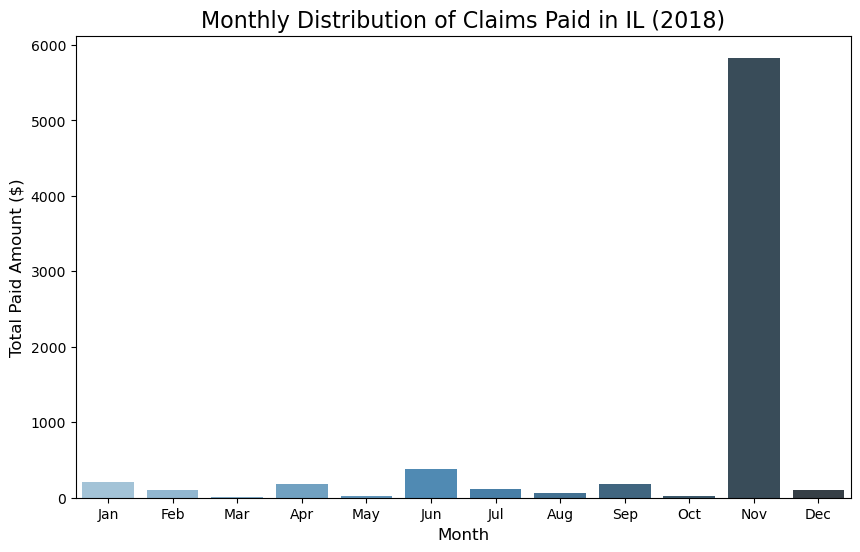

In [70]:
#1. Visualization for IL Claims Paid in 2018
import matplotlib.pyplot as plt
import seaborn as sns

il_claims_2018['Month'] = il_claims_2018['Received_DT'].dt.month

monthly_claims = il_claims_2018.groupby('Month')['Paid_Amount'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_claims.index, y=monthly_claims.values, palette='Blues_d')
plt.title('Monthly Distribution of Claims Paid in IL (2018)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Paid Amount ($)', fontsize=12)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


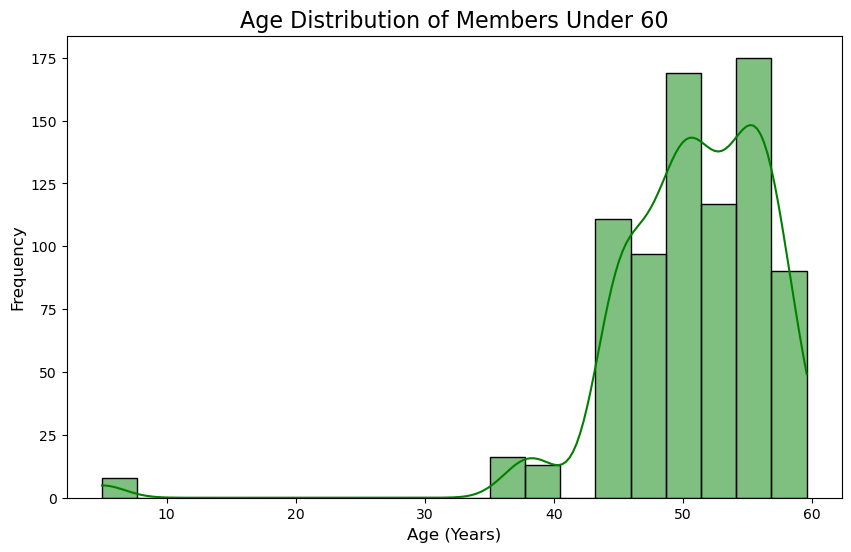

In [71]:
#2. Visualization histogram for Members Under 60
plt.figure(figsize=(10, 6))
sns.histplot(members_under_60['Age'], bins=20, kde=True, color='green')
plt.title('Age Distribution of Members Under 60', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


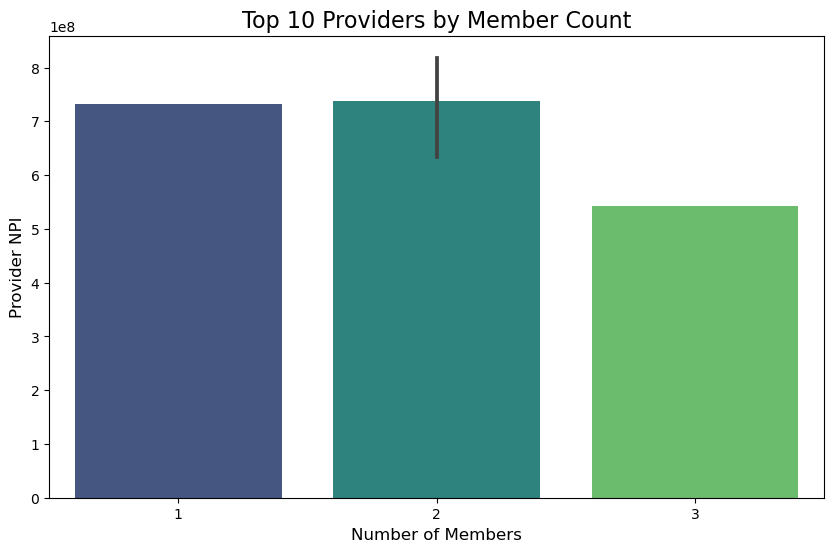

In [72]:
#3. Visualization for Member-to-Provider Attribution
top_providers = provider_member_count.sort_values(by='Member_Count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_providers['Member_Count'], y=top_providers['Provider_NPI'], palette='viridis')
plt.title('Top 10 Providers by Member Count', fontsize=16)
plt.xlabel('Number of Members', fontsize=12)
plt.ylabel('Provider NPI', fontsize=12)
plt.show()